In [1]:
from tc_size_rainfall.config import FIGURE_DIR, DATA_DIR, RAW_DIR, PROCESSED_DIR, OUTPUT_DIR
from tc_size_rainfall.geospatial import configurar_mapa

In [2]:
# 0. Preparación de ambientes necesarios

# Importar librerias
import pandas as pd
import xarray as xr
import numpy as np

import os
import errno
import geopandas as gpd
import seaborn as sns


import shapely
from shapely.geometry import shape, Polygon, Point, MultiPoint, box, LineString

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

import cartopy
from cartopy import config
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader as sf
import cartopy.feature as cfeature


from mpl_toolkits.axes_grid1 import make_axes_locatable


from cmcrameri import cm

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
from cmcrameri import cm as ccm

In [4]:
# Extremos dentro de ciclones tropicales archivos para pacifico y atlantico
ext_na = pd.read_csv(PROCESSED_DIR / 'resultados_extremos_total_na.csv')
ext_ep = pd.read_csv(PROCESSED_DIR / 'resultados_extremos_total_ep.csv')
extremos = pd.concat([ext_na,ext_ep], ignore_index  =True)

In [5]:
td_na = ext_na[ext_na.MWS < 63]                                # Depresión Tropical
tt_na = ext_na[(ext_na.MWS >= 63) & (ext_na.MWS < 118)]        # Tormenta Tropical
h1_2_na = ext_na[(ext_na.MWS >= 118) & (ext_na.MWS <= 177)]      # Huracanes Cat 1-2
h3_5_na = ext_na[ext_na.MWS >= 177]                             # Huracanes Cat 3-5

# Cuenca: Pacífico Este
td_ep = ext_ep[ext_ep.MWS < 63]
tt_ep = ext_ep[(ext_ep.MWS >= 63) & (ext_ep.MWS < 118)]
h1_2_ep = ext_ep[(ext_ep.MWS >= 118) & (ext_ep.MWS < 177)]
h3_5_ep = ext_ep[ext_ep.MWS >= 177]

In [6]:
import geopandas as gpd
import cartopy.io.shapereader as shpreader

# Ruta al shapefile de Natural Earth gestionado por Cartopy
shp_path = shpreader.natural_earth(
    resolution="110m",
    category="cultural",
    name="admin_0_countries"
)

# Leer con GeoPandas
world = gpd.read_file(shp_path)

# Filtrar Norteamérica
NAshape = world[world["CONTINENT"] == "North America"]

# Separar geometrías multiparte
NAs = NAshape.explode(index_parts=False).reset_index(drop=True)

/home/apereze/miniforge3/envs/tc-size-rainfall/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


In [7]:
gdfNA = gpd.GeoDataFrame(ext_na, geometry= [shapely.geometry.Point(xy) for xy in zip(ext_na.lon_p, ext_na.lat_p)])
gdfEP = gpd.GeoDataFrame(ext_ep, geometry= [shapely.geometry.Point(xy) for xy in zip(ext_ep.lon_p, ext_ep.lat_p)])

In [8]:
def gdf_explode(gdf):
    """ Separación (explode) de una GeoDataFrame en columnas"""
    return gdf.explode().reset_index(drop=True).rename(columns={0: 'geometry'})

def geodf(gdfNA,NAs):
    """Programa que selecciona las intersecciones de los CTs en el area de estudio
    - gdfNA es un geodataframe con información ce posiciones de los CTs
    - NAs es el shape del territorio del cual nos interesa conocer donde hay información """
    sel  = pd.DataFrame()
    for i in range(len(NAs)):
        indx = gdfNA['geometry'].intersects(NAs['geometry'][i])
        landfall = gdfNA.loc[indx]
        sel = pd.concat([sel, landfall])
    return sel
def geodf_ri(gdfNA,NAs):
    gdfNA = gdfNA.reset_index(drop=True)
    sel  = pd.DataFrame()
    for i in range(len(NAs)):
        indx = gdfNA['geometry'].intersects(NAs['geometry'][i])
        landfall = gdfNA.loc[indx]
        sel = pd.concat([sel, landfall])
    return sel

In [9]:
lfna = geodf(gdfNA, NAs)
lfep = geodf(gdfEP, NAs)

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

def HistBox(variables, df):
    # Configuración de la figura y los parámetros de estilo
    plt.figure(figsize=(20, 20))
    outer_grid = gridspec.GridSpec(5, 2, wspace=0.2, hspace=0.4)
    custom_params = {"axes.spines.right": True, "axes.spines.top": True, "axes.spines.left": True}
    sns.set_theme(style='whitegrid', context="talk", rc=custom_params, color_codes=True)
    sns.set_style("ticks", {"axes.grid": True, "grid.linestyle": "--"})

    for i, variable in enumerate(variables):
        inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1,
                                                      subplot_spec=outer_grid[i],
                                                      height_ratios=[4, 1],
                                                      hspace=0.02)  # Ajustado para minimizar el espacio entre histogramas y boxplots

        # Histograma con frecuencia
        ax_hist = plt.Subplot(plt.gcf(), inner_grid[0])
        sns.histplot(df[variable], stat='frequency', color='yellowgreen', ax=ax_hist, binwidth=100)
        ax_hist.set_xlabel('')  # Mantener esto para limpieza
        plt.gcf().add_subplot(ax_hist)
        ax_hist.tick_params(axis='x',          # Cambios para ocultar solo los ticks (no las etiquetas, que ya están ocultas)
                            which='both',      # Afecta a ticks mayores y menores
                            bottom=False,      # Oculta ticks inferiores
                            top=False,         # Oculta ticks superiores (si estuvieran visibles)
                            labelbottom=False) # Oculta las etiquetas de los ticks inferiores

        ax_hist.grid(True)

        # Boxplot
        ax_box = plt.Subplot(plt.gcf(), inner_grid[1], sharex=ax_hist)
        sns.boxplot(x=df[variable], ax=ax_box, color='lightgreen', showmeans=True,
                    meanprops={"marker":"o", "markerfacecolor":'red',
                               "markeredgecolor":"gray", "markersize":10})
        ax_box.set_xlabel('Distance from the center')
        ax_box.tick_params(axis='x',          # Cambios para ocultar solo los ticks (no las etiquetas, que ya están ocultas)
                            which='both',      # Afecta a ticks mayores y menores
                            bottom=True,      # Oculta ticks inferiores
                            top=True,         # Oculta ticks superiores (si estuvieran visibles)
                            labelbottom=True)
        plt.gcf().add_subplot(ax_box)

    # Mostrar el gráfico
    plt.show()
# 

In [13]:
def clasificar_saffir_simpson(mws_kmh):
    if mws_kmh < 63:
        return "TD"
    elif mws_kmh < 119:
        return "TS"
    elif mws_kmh < 178:
        return "Min Hur"
    else:
        return "Maj Hur"

# Clasificación
lfna['cat'] = lfna['MWS'].apply(clasificar_saffir_simpson)
lfep['cat'] = lfep['MWS'].apply(clasificar_saffir_simpson)


In [14]:
filt_na = lfna[lfna.r.le(1500)].copy()
filt_ep = lfep[lfep.r.le(1500)].copy()

In [16]:
outer_grid = gridspec.GridSpec(5, 2, wspace=0.2, hspace=0.4)
custom_params = {"axes.spines.right": True, "axes.spines.top": True, "axes.spines.left": True}
sns.set_theme(style='whitegrid', context="talk", rc=custom_params, color_codes=True)
sns.set_style("ticks", {"axes.grid": True, "grid.linestyle": "--"})

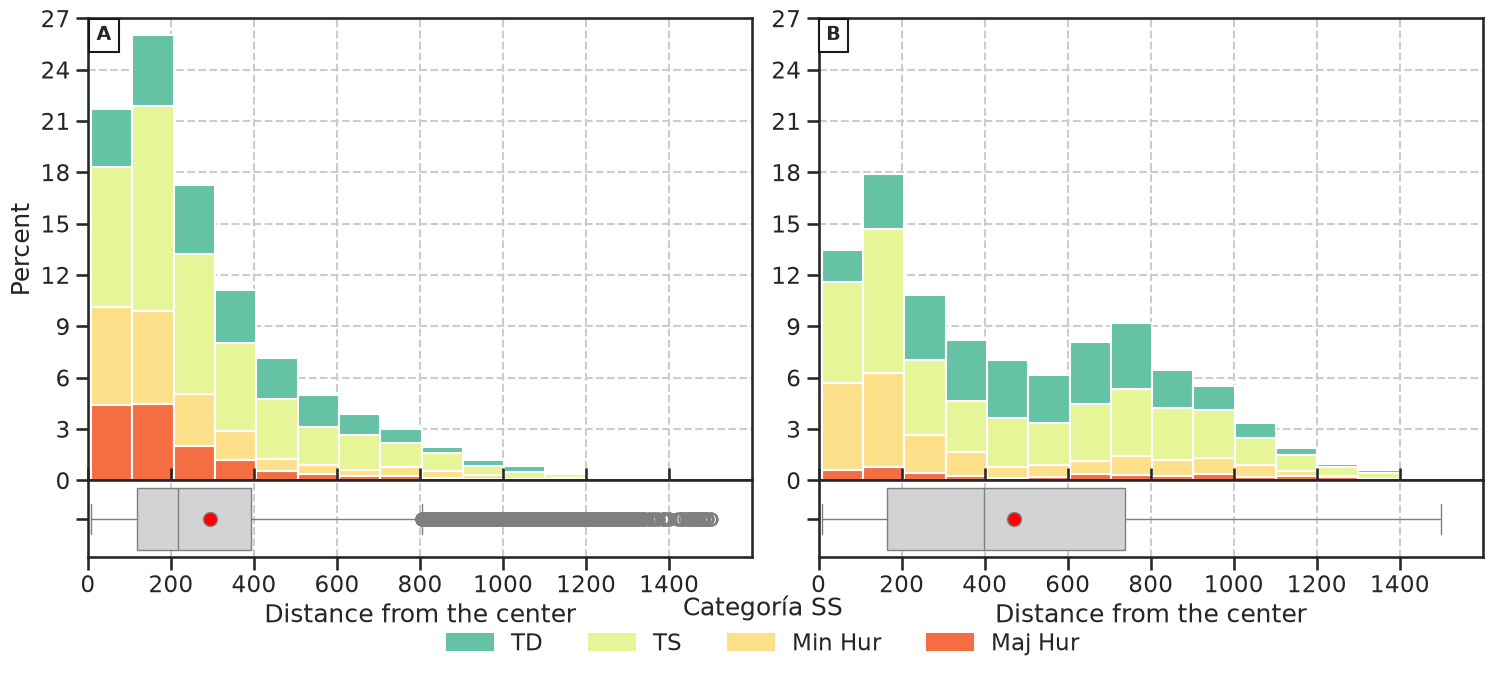

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

def HistBox(variables, df, ax_hist, ax_box, orden_categorias, colores):
    # Histograma apilado por categoría con bins de 100 km
    sns.histplot(
        data=df,
        x=variables,
        hue='cat_1',
        multiple="stack",
        stat='percent',
        palette=colores,
        alpha=1,
        legend=False,
        ax=ax_hist,
        binwidth=100
    )

    # Configuración del histograma
    ax_hist.set_xlabel('')
    ax_hist.tick_params(axis='x', bottom=False, top=False, labelbottom=False)
    ax_hist.grid(True)

    x_ticks = range(0, 1600, 200)
    ax_hist.set_xticks(x_ticks)
    ax_hist.set_xlim([0, 1600])
    ax_hist.set_yticks(range(0, 28, 3))
    ax_hist.set_ylim([0, 27])

    # Boxplot
    sns.boxplot(
        data=df,
        x=variables,
        ax=ax_box,
        color='lightgrey',
        showmeans=True,
        meanprops={"marker": "o", "markerfacecolor": 'red', "markeredgecolor": "gray", "markersize": 10}
    )

    ax_box.set_xlabel('Distance from the center')
    ax_box.tick_params(axis='x', bottom=True, top=True, labelbottom=True)
    ax_box.set_xticks(x_ticks)
    ax_box.set_xlim([0, 1600])

    # Leyenda con parches de colores
    handles = [
        mpatches.Patch(color=colores[i], label=cat)
        for i, cat in enumerate(orden_categorias)
    ]
    return handles


# ============================================
# Configuración de categorías y colores
# ============================================
orden_categorias = ['TD', 'TS', 'Min Hur', 'Maj Hur']  # ✅ orden solicitado
colores = sns.color_palette('Spectral_r', n_colors=4)

# Asegurar orden en la columna 'cat'
for df in [filt_na, filt_ep]:
    df['cat_1'] = pd.Categorical(df['cat'], categories=orden_categorias, ordered=True)

# ============================================
# Crear figura con dos paneles
# ============================================
fig = plt.figure(figsize=(18, 7))
outer_grid = gridspec.GridSpec(1, 2, wspace=0.1, hspace=0.3)

# Panel 1 - Atlántico Norte
inner_grid1 = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[0], height_ratios=[6, 1], hspace=0)
ax_hist1 = plt.Subplot(fig, inner_grid1[0])
ax_box1 = plt.Subplot(fig, inner_grid1[1])
fig.add_subplot(ax_hist1)
fig.add_subplot(ax_box1)

handles = HistBox('r', filt_na, ax_hist1, ax_box1, orden_categorias, colores)
# ax_hist1.set_title(r'$\mathbf{A.}$ NA Basin', fontsize=16)

# ✅ Etiqueta "A" en el panel izquierdo
ax_hist1.text(
    0.037, 0.963, r'$\mathbf{A}$',
    transform=ax_hist1.transAxes,
    fontsize=14, fontweight='bold',
    ha='right', va='center',
    bbox=dict(facecolor='w', edgecolor='k', pad=5.0),
    zorder=5
)

# Panel 2 - Pacífico Oriental
inner_grid2 = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[1], height_ratios=[6, 1], hspace=0)
ax_hist2 = plt.Subplot(fig, inner_grid2[0])
ax_box2 = plt.Subplot(fig, inner_grid2[1])
fig.add_subplot(ax_hist2)
fig.add_subplot(ax_box2)

HistBox('r', filt_ep, ax_hist2, ax_box2, orden_categorias, colores)
# ax_hist2.set_title(r'$\mathbf{B.}$ EP Basin', fontsize=16)
ax_hist2.set_ylabel('')

# ✅ Etiqueta "B" en el panel derecho
ax_hist2.text(
    0.034, 0.963, r'$\mathbf{B}$',
    transform=ax_hist2.transAxes,
    fontsize=14, fontweight='bold',
    ha='right', va='center',
    bbox=dict(facecolor='w', edgecolor='k', pad=5.0),
    zorder=5
)

# ============================================
# Leyenda global
# ============================================
fig.legend(
    handles,
    orden_categorias,
    title="Categoría SS",
    loc='lower center',
    bbox_to_anchor=(0.5, -0.06),
    ncol=4,
    frameon=False
)

plt.show()
# fig.savefig("figure_10_FINAL.jpeg", dpi=300, bbox_inches='tight')
